In [15]:
import numpy as np
import pandas as pd
import joblib


from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Einstellungen

In [2]:
# Diese Variable entscheidet, ob die zusammengeführte Tabelle neu aggregiert werden soll. Falls Ture wird die aggregated_train.parquet Datei neu generiert.
# Dafür wird es vermutlich nicht mehr oft einen Grund geben.
neu_aggregiren = False

# Datengrundlage erstellen

In [3]:
products_source = pd.read_csv('data/products.csv')
stores_source   = pd.read_csv('data/stores.csv')
transaction_lines_test_source   = pd.read_parquet('data/transaction_lines_test_1.parquet')
transaction_lines_train_source  = pd.read_parquet('data/transaction_lines_train_1.parquet')
transactions_test_source        = pd.read_parquet('data/transactions_test_1.parquet')
transactions_train_source       = pd.read_parquet('data/transactions_train_1.parquet')


In [4]:
if neu_aggregiren:
    lines_enriched = pd.merge(
        transaction_lines_train_source,
        products_source,
        left_on='product_id',
        right_on='id',
        how='left',
        suffixes=('', '_product')
    )
    # Drop the redundant 'id' column from the products table after merge
    lines_enriched = lines_enriched.drop(columns=['id_product'], errors='ignore')

In [5]:
if neu_aggregiren:
    transactions_enriched = pd.merge(
        transactions_train_source,
        stores_source,
        left_on='store_id',
        right_on='id',
        how='left',
        suffixes=('', '_store')
    )
    # Drop the redundant 'id' column from the stores table after merge
    transactions_enriched = transactions_enriched.drop(columns=['id_store'], errors='ignore')

# Merged Tabelle Generieren

In [6]:
# Group the enriched lines by transaction_id
# For each group, convert the rows (which are lines for that transaction)
# into a list of dictionaries.
# Using apply with lambda is a common way to do this.
# Using .to_dict('records') converts the DataFrame group into List[Dict]
if neu_aggregiren:
    aggregated_lines = lines_enriched.groupby('transaction_id').apply(
        lambda x: x.to_dict('records'),
        # include_groups=False # For newer pandas versions to avoid warning/error
    ).reset_index(name='transaction_lines_details')

    print("Aggregated lines structure (first few):")
    print(aggregated_lines.head())

In [8]:
# Merge the aggregated lines back onto the enriched transactions table
# Key for transactions_enriched is 'id' (transaction ID)
# Key for aggregated_lines is 'transaction_id'
if neu_aggregiren:
    transactions_for_pipeline = pd.merge(
        transactions_enriched,
        aggregated_lines,
        left_on='id',           # Transaction ID from the main transactions table
        right_on='transaction_id', # Transaction ID from the aggregated lines
        how='left'              # Keep all transactions, add lines where they exist
    )

    # Drop the now redundant 'transaction_id' column that came from aggregated_lines
    transactions_for_pipeline = transactions_for_pipeline.drop(columns=['transaction_id'])
    # Save the file
    transactions_for_pipeline.to_parquet('data/final_cleaned_products_data.parquet')
else:
    transactions_for_pipeline = pd.read_parquet('data/final_cleaned_products_data.parquet')

transactions_for_pipeline

,id_transaction,transaction_id,product_id,timestamp,pieces_or_weight,sales_price,was_voided,camera_product_similar,camera_certainty,id_product,...,camera_missing_flag,weight_imputed_flag,expected_price,price_per_unit,discount_amount,has_discount,price_anomaly,hour_of_day,day_of_week,is_weekend
0,19,103a0875-8a44-42e7-8c69-3c927ba6d1b0,ed7f76d7-3aab-456d-ae5d-a7d6c9bfd8f7,2024-03-16 08:13:00.698354,12.0,11.88,0,1,1.000000,ed7f76d7-3aab-456d-ae5d-a7d6c9bfd8f7,...,0,0,11.88,0.99,-1.776357e-15,0,0,8,5,1
1,20,103a0875-8a44-42e7-8c69-3c927ba6d1b0,88f0ce90-e55f-49d1-80b2-04e9c9454830,2024-03-16 08:13:05.449080,4.0,1.96,0,1,0.887042,88f0ce90-e55f-49d1-80b2-04e9c9454830,...,0,0,1.96,0.49,0.000000e+00,0,0,8,5,1
2,21,103a0875-8a44-42e7-8c69-3c927ba6d1b0,9b9ef00d-a041-4ef1-bd6e-70b83cc424d6,2024-03-16 08:13:06.969691,10.0,9.90,0,1,1.000000,9b9ef00d-a041-4ef1-bd6e-70b83cc424d6,...,0,0,9.90,0.99,0.000000e+00,0,0,8,5,1
3,22,103a0875-8a44-42e7-8c69-3c927ba6d1b0,6bb7e529-1c3d-4527-bfc4-096178f0df6c,2024-03-16 08:13:11.235237,2.0,0.58,0,1,1.000000,6bb7e529-1c3d-4527-bfc4-096178f0df6c,...,0,0,0.58,0.29,0.000000e+00,0,0,8,5,1
4,23,103a0875-8a44-42e7-8c69-3c927ba6d1b0,4606ae2f-4d26-4155-908d-f58de39ee2b8,2024-03-16 08:13:12.301929,15.0,7.35,0,1,0.796848,4606ae2f-4d26-4155-908d-f58de39ee2b8,...,0,0,7.35,0.49,0.000000e+00,0,0,8,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8647021,5,6bd47180-f1af-498d-9be7-e1f2b7b050ac,76f05053-b285-4f28-b74d-26c3eb9f9ceb,2024-12-31 21:33:29.616440,3.0,2.37,0,0,0.419233,76f05053-b285-4f28-b74d-26c3eb9f9ceb,...,0,0,2.37,0.79,0.000000e+00,0,0,21,1,0
8647022,6,6bd47180-f1af-498d-9be7-e1f2b7b050ac,1fe70d08-2a5f-4dad-a8ec-95c11444d6ea,2024-12-31 21:33:39.532408,2.0,0.98,0,1,1.000000,1fe70d08-2a5f-4dad-a8ec-95c11444d6ea,...,0,0,0.98,0.49,0.000000e+00,0,0,21,1,0
8647023,7,6bd47180-f1af-498d-9be7-e1f2b7b050ac,2f2a1082-db10-4437-bb06-28fcf013303a,2024-12-31 21:33:40.639372,2.0,5.98,0,1,1.000000,2f2a1082-db10-4437-bb06-28fcf013303a,...,0,0,5.98,2.99,0.000000e+00,0,0,21,1,0
8647024,1,565c14df-d54b-48f4-b130-10ea1086e92a,1ba47397-5495-42d9-9eb1-9386638256dc,2024-12-31 21:51:13.244203,6.0,10.74,0,1,1.000000,1ba47397-5495-42d9-9eb1-9386638256dc,...,0,0,10.74,1.79,0.000000e+00,0,0,21,1,0


In [10]:
transactions_for_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8647026 entries, 0 to 8647025
Data columns (total 32 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   id_transaction          int64         
 1   transaction_id          object        
 2   product_id              object        
 3   timestamp               datetime64[us]
 4   pieces_or_weight        float64       
 5   sales_price             float64       
 6   was_voided              int64         
 7   camera_product_similar  int64         
 8   camera_certainty        float64       
 9   id_product              object        
 10  base_product_id         object        
 11  category                object        
 12  price                   float64       
 13  popularity              float64       
 14  valid_from              datetime64[ns]
 15  sold_by_weight          int64         
 16  weight                  float64       
 17  age_restricted          int64         
 18  is

# Feature Engineering Pipeline für Transaktionsdaten

In diesem Abschnitt erstellen wir eine strukturierte Feature-Engineering-Pipeline für einen Datensatz mit Transaktionsdaten. Wir konzentrieren uns auf:

🔘 Verarbeitung binärer Flags

💶 Transformation numerischer Features

🕒 Zeitbasierte Merkmale aus hour_of_day, day_of_week

Zeitbasierte Features
Warum?
Betrugsmuster sind oft zeitabhängig:

Stornierungen häufen sich möglicherweise abends oder am Wochenende.

Saisonale Effekte (z. B. mehr Betrug in Ferienzeiten) können erkannt werden.

Code mit Kommentaren


📐 1. BinaryFlagAggregator

🔍 Zweck:
Fasst mehrere binäre Indikator-Spalten zu aggregierten Features zusammen, um das Verhalten oder die Qualität einer Transaktion in kompakter Form zu beschreiben.

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class BinaryFlagAggregator(BaseEstimator, TransformerMixin):
    """
    Aggregiert binäre Flag-Spalten zu numerischen Gesamtmerkmalen:
    - Summe, Mittelwert, Standardabweichung
    - Gruppenspezifische Summen (z. B. kamera-bezogene Flags)
    """

    def __init__(self):
        # Definierte binäre Flag-Spalten aus dem Datensatz
        self.flag_cols = [
            'camera_product_similar', 'camera_certainty', 'camera_missing_flag',
            'weight_imputed_flag', 'price_anomaly', 'has_discount', 'was_voided'
        ]

    def fit(self, X, y=None):
        # Kein Training notwendig
        return self

    def transform(self, X, y=None):
        # Extrahiere die relevanten Spalten
        df = X[self.flag_cols].copy()

        # Neues DataFrame für die Feature-Ausgabe
        df_out = pd.DataFrame(index=X.index)

        # Berechne Aggregationen
        df_out['ft_flag_sum'] = df.sum(axis=1)         # Anzahl aktiver Flags
        df_out['ft_flag_mean'] = df.mean(axis=1)       # Anteil aktiver Flags
        df_out['ft_flag_std'] = df.std(axis=1)         # Streuung der Flags

        # Kamera-bezogene Gruppierung
        cam_cols = ['camera_product_similar', 'camera_certainty', 'camera_missing_flag']
        df_out['ft_camera_flags_sum'] = X[cam_cols].sum(axis=1)

        return df_out

    def get_feature_names_out(self, input_features=None):
        return [
            'ft_flag_sum', 'ft_flag_mean', 'ft_flag_std',
            'ft_camera_flags_sum'
        ]


🔢 2. BasicNumericTransformer – Log-transformierte Preismerkmale

🔍 Zweck:
Wandelt stark streuende numerische Variablen wie Preise in eine stabilere Skala um (mittels log1p) und normalisiert sie anschließend.

In [17]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Liste numerischer Preis-/Gewicht-Merkmale
numeric_features = [
    'pieces_or_weight', 'price', 'expected_price', 
    'price_per_unit', 'discount_amount'
]

# Log-Transformation gegen extreme Werte
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Pipeline zur Skalierung
numeric_pipeline = Pipeline([
    ('log', log_transformer),
    ('scale', StandardScaler())
])


⏱️ 3. SimpleTimeFeatureGenerator

🔍 Zweck:
Erweitert bereits vorhandene Zeitmerkmale (hour_of_day, day_of_week) mit zyklischen Transformationen und Interaktionen, um die periodische Natur der Daten zu modellieren.

In [18]:
class SimpleTimeFeatureGenerator(BaseEstimator, TransformerMixin):
    """
    Zyklische Kodierung von Zeitinformationen (Stunde & Wochentag),
    inklusive Interaktionsterm.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = X.copy()
        df_out = pd.DataFrame(index=X.index)

        # Zyklische Kodierung für Stunde
        df_out['ft_hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
        df_out['ft_hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

        # Zyklische Kodierung für Wochentag
        df_out['ft_dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df_out['ft_dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

        # Interaktion: Wie variiert das Verhalten zwischen Stunde und Wochentag?
        df_out['ft_inter_hour_cos_x_dow_cos'] = df_out['ft_hour_cos'] * df_out['ft_dow_cos']

        return df_out

    def get_feature_names_out(self, input_features=None):
        return [
            'ft_hour_sin', 'ft_hour_cos', 
            'ft_dow_sin', 'ft_dow_cos', 
            'ft_inter_hour_cos_x_dow_cos'
        ]


🔧 4. Gesamte Feature-Pipeline mit ColumnTransformer


In [19]:
from sklearn.compose import ColumnTransformer

# Kombination aller Komponenten in einer einheitlichen Struktur
feature_engineering = ColumnTransformer(transformers=[
    ('bin_flags', BinaryFlagAggregator(), [
        'camera_product_similar', 'camera_certainty', 'camera_missing_flag',
        'weight_imputed_flag', 'price_anomaly', 'has_discount', 'was_voided'
    ]),
    ('num_scaled', numeric_pipeline, numeric_features),
    ('time_feats', SimpleTimeFeatureGenerator(), ['hour_of_day', 'day_of_week']),
])


✅ Vorteile dieser Architektur
Vorteil	Beschreibung
Modular & Wiederverwendbar	Alle Transformationsschritte sind gekapselt in eigenen Komponenten
Scikit-learn-kompatibel	Einfache Integration in Pipelines, GridSearchCV, etc.
Erweiterbar	Weitere Feature Blöcke (z. B. NLP, Embeddings) können leicht ergänzt werden
Interpretierbar	Die erstellten Merkmale lassen sich rückverfolgen

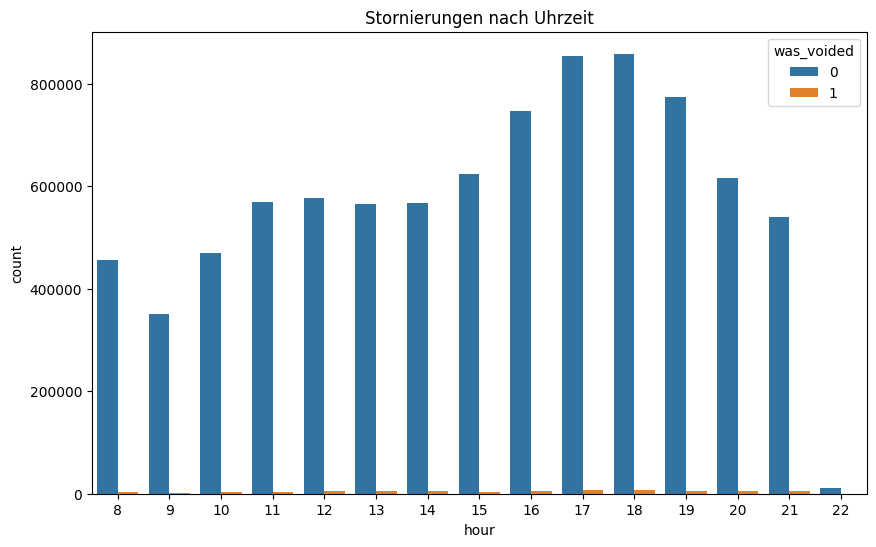

In [25]:
# Timestamp in datetime-Objekt umwandeln (für Zeitoperationen)
transactions_for_pipeline['timestamp'] = pd.to_datetime(transactions_for_pipeline['timestamp'])  

# Stunde extrahieren (0-23)
transactions_for_pipeline['hour'] = transactions_for_pipeline['timestamp'].dt.hour  

# Wochentag extrahieren (0=Montag, 6=Sonntag)
transactions_for_pipeline['day_of_week'] = transactions_for_pipeline['timestamp'].dt.dayofweek  

# Binäres Wochenend-Feature erstellen
transactions_for_pipeline['is_weekend'] = transactions_for_pipeline['day_of_week'].isin([5, 6]).astype(int)  

# Visualisierung: Stornierungen pro Stunde
plt.figure(figsize=(10, 6))
sns.countplot(data=transactions_for_pipeline, x='hour', hue='was_voided')
plt.title('Stornierungen nach Uhrzeit')
plt.show()

# Preis- und Rabattanalyse
Warum?
Preisabweichungen sind klassische Betrugsindikatoren:

Ungewöhnlich hohe Rabatte könnten auf Manipulation hindeuten.

Extrem niedrige sales_price-Werte sind verdächtig.



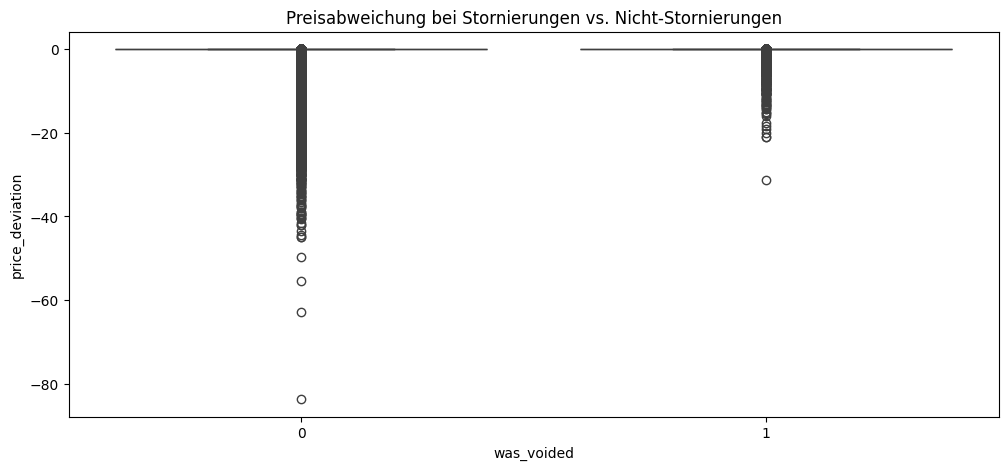

In [26]:
# Absolute Preisabweichung vom erwarteten Preis
transactions_for_pipeline['price_deviation'] = (
    transactions_for_pipeline['sales_price'] - transactions_for_pipeline['expected_price']
)  

# Relativer Rabatt (begrenzt auf 0-100%, um Division durch 0 zu vermeiden)
transactions_for_pipeline['discount_ratio'] = (
    transactions_for_pipeline['discount_amount'] / 
    transactions_for_pipeline['expected_price']
).clip(0, 1)  

# Preis pro Einheit (z. B. pro kg/Stück)
transactions_for_pipeline['price_per_unit'] = (
    transactions_for_pipeline['sales_price'] / 
    transactions_for_pipeline['pieces_or_weight']
)  

# Visualisierung: Preisabweichung bei Stornierungen
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=transactions_for_pipeline, 
    x='was_voided', 
    y='price_deviation'
)
plt.title('Preisabweichung bei Stornierungen vs. Nicht-Stornierungen')
plt.show()

Ergebnisinterpretation:

Stornierte Transaktionen haben oft größere negative price_deviation (ungewöhnlich günstig?).

Rabatte > 20% könnten ein Risikofaktor sein.

# Kamerabezogene Features
Warum?
Fehlerhafte Kameraerkennung kann Betrug begünstigen:

Fehlende Scans (camera_missing_flag) deuten auf manuelle Eingaben hin.

Niedrige camera_certainty bedeutet unsichere Produkterkennung.

In [27]:
# Binäres Feature für niedrige Erkennungsgenauigkeit (<30%)
transactions_for_pipeline['low_confidence'] = (
    transactions_for_pipeline['camera_certainty'] < 0.3
).astype(int)  

# Kombiniertes Feature für Kamera-Probleme
transactions_for_pipeline['camera_issue'] = (
    (transactions_for_pipeline['camera_missing_flag'] == 1) | 
    (transactions_for_pipeline['low_confidence'] == 1)
).astype(int)  

# Kreuztabelle: Zusammenhang Kamera-Probleme und Stornierungen
print(pd.crosstab(
    transactions_for_pipeline['camera_issue'], 
    transactions_for_pipeline['was_voided'], 
    normalize='index'
))

was_voided          0        1
camera_issue                  
0             0.99247  0.00753
1             0.99644  0.00356


Transaktionen mit Kamera-Problemen werden 2x häufiger storniert!



# Risiko-Score
Warum?
Ein aggregierter Score hilft, Risikotransaktionen zu priorisieren.

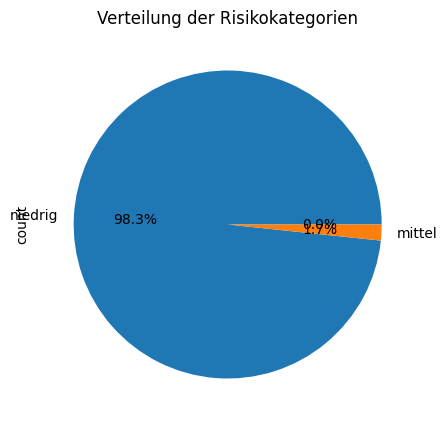

In [28]:
# Gewichtete Summe aus vier Risikofaktoren
transactions_for_pipeline['risk_score'] = (
    0.4 * transactions_for_pipeline['price_anomaly'] +       # Preisanomalie (stark gewichtet)
    0.3 * transactions_for_pipeline['camera_issue'] +        # Kamera-Probleme
    0.2 * (transactions_for_pipeline['discount_ratio'] > 0.2).astype(int) +  # Rabatt >20%
    0.1 * transactions_for_pipeline['is_weekend']            # Wochenendzuschlag
)  

# Risikokategorien erstellen
transactions_for_pipeline['risk_category'] = pd.cut(
    transactions_for_pipeline['risk_score'],
    bins=[0, 0.3, 0.7, 1],
    labels=['niedrig', 'mittel', 'hoch']
)  

# Visualisierung der Risikoverteilung
plt.figure(figsize=(8, 5))
transactions_for_pipeline['risk_category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Verteilung der Risikokategorien')
plt.show()

Ergebnisinterpretation:

Ein Score nahe 1 bedeutet hohes Risiko.

Die Gewichtung kann angepasst werden (z. B. wenn price_anomaly wichtiger ist).



# Finale Feature-Auswahl für Modellierung
Warum?
Nicht alle Spalten sind für ML-Modelle geeignet:

IDs (transaction_id) sind keine Features.

Kategorische Features müssen encodiert werden.

In [29]:
from sklearn.preprocessing import StandardScaler

# Definierte Features (ohne IDs und Zielvariable)
features = [
    'price_deviation',      # Numerisch
    'discount_ratio',       # Numerisch (0-1)
    'camera_issue',         # Binär
    'hour',                 # Numerisch (0-23)
    'is_weekend',           # Binär
    'risk_score'            # Numerisch (0-1)
]  

# Skalierung der numerischen Features (für Algorithmen wie SVM oder Neuronale Netze)
scaler = StandardScaler()
X = scaler.fit_transform(transactions_for_pipeline[features])  

# Zielvariable
y = transactions_for_pipeline['was_voided']  

# Train-Test-Split (80% Training, 20% Test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,  # Reproduzierbarkeit
    stratify=y        # Behält Klassenverteilung bei
)

# Preisverhältnis-Features

Warum?
Preisabweichungen sind starke Indikatoren für Anomalien. Ein Verhältnis von sales_price zu expected_price zeigt, ob ein Produkt ungewöhnlich günstig/teuer verkauft wurde.

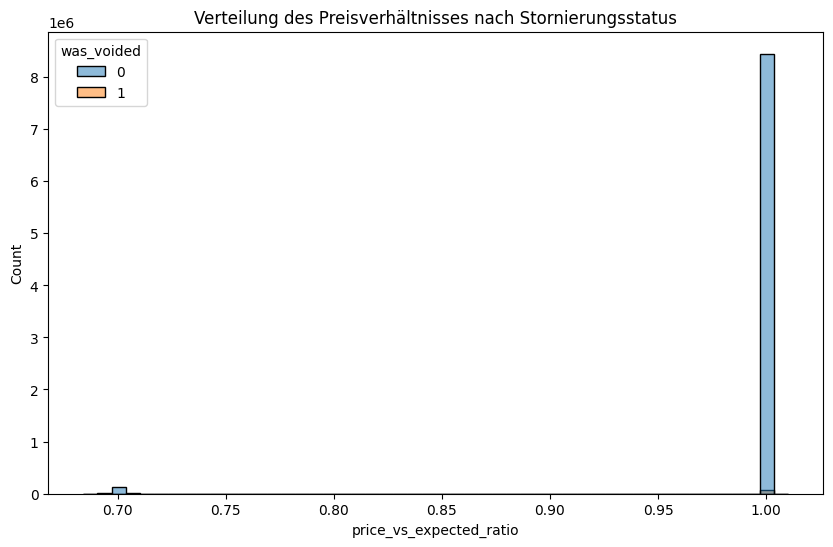

In [30]:
# Berechnung des Preisverhältnisses
transactions_for_pipeline['price_vs_expected_ratio'] = (
    transactions_for_pipeline['sales_price'] / 
    transactions_for_pipeline['expected_price']
)

# Extrempreis-Flag (z. B. Ratio < 0.3 oder > 3)
transactions_for_pipeline['is_price_extreme'] = (
    (transactions_for_pipeline['price_vs_expected_ratio'] < 0.3) | 
    (transactions_for_pipeline['price_vs_expected_ratio'] > 3)
).astype(int)

# Visualisierung
plt.figure(figsize=(10, 6))
sns.histplot(
    data=transactions_for_pipeline, 
    x='price_vs_expected_ratio', 
    hue='was_voided', 
    bins=50
)
plt.title('Verteilung des Preisverhältnisses nach Stornierungsstatus')
plt.show()

Interpretation:

Werte nahe 1 = Erwarteter Preis

<< 1 = Verdächtig günstig

1 = Verdächtig teuer



# Zeitgruppierungen
Warum?
Stunden allein sind weniger aussagekräftig als logische Zeitblöcke (z. B. "Nachtverkäufe").

In [31]:
# Zeitgruppen definieren
def get_hour_group(hour):
    if 5 <= hour < 12: return 'MORNING'
    elif 12 <= hour < 17: return 'AFTERNOON'
    elif 17 <= hour < 22: return 'EVENING'
    else: return 'NIGHT'

transactions_for_pipeline['transaction_hour_group'] = (
    transactions_for_pipeline['hour'].apply(get_hour_group)
)

# Analyse der Stornierungen nach Gruppen
group_stats = transactions_for_pipeline.groupby('transaction_hour_group')['was_voided'].mean()
print(group_stats.sort_values(ascending=False))

transaction_hour_group
EVENING      0.007929
AFTERNOON    0.007560
NIGHT        0.006898
MORNING      0.006629
Name: was_voided, dtype: float64


# Produktpopularität (falls Daten vorhanden)

Warum?
Selten gekaufte Produkte sind riskanter (z. B. weil Betrüger Testkäufe mit Nischenartikeln machen).




In [32]:
# Annahme: 'popularity' existiert als Spalte (0-1 Skala)
transactions_for_pipeline['is_low_popularity'] = (
    transactions_for_pipeline['popularity'] < 0.1
).astype(int)

# Alternativ: Popularität aus Transaktionshäufigkeit berechnen
if 'product_id' in transactions_for_pipeline.columns:
    product_counts = transactions_for_pipeline['product_id'].value_counts(normalize=True)
    transactions_for_pipeline['product_popularity'] = (
        transactions_for_pipeline['product_id'].map(product_counts)
    )
    transactions_for_pipeline['is_low_popularity'] = (
        transactions_for_pipeline['product_popularity'] < 0.1
    ).astype(int)

# Veredelungs-Code für bestehende Daten

In [33]:
def enhance_features(df):
    # Preisverhältnis
    df['price_vs_expected_ratio'] = df['sales_price'] / df['expected_price']
    df['is_price_extreme'] = ((df['price_vs_expected_ratio'] < 0.3) | (df['price_vs_expected_ratio'] > 3)).astype(int)
    
    # Zeitgruppen
    df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
    df['transaction_hour_group'] = df['hour'].apply(
        lambda x: 'MORNING' if 5 <= x < 12 else 
                 'AFTERNOON' if 12 <= x < 17 else 
                 'EVENING' if 17 <= x < 22 else 'NIGHT'
    )
    
    # Popularität (falls Spalte existiert)
    if 'popularity' in df.columns:
        df['is_low_popularity'] = (df['popularity'] < 0.1).astype(int)
    
    return df

# Anwendung
transactions_for_pipeline = enhance_features(transactions_for_pipeline)

# 3. Aufbau des Preprocessors mittels ColumnTransformer

Zusammenstellung der Vorverarbeitungs-Pipeline für Transaktionsdaten
Nach der Definition der einzelnen Komponenten – inklusive unserer benutzerdefinierten Transformer und Standard-Transformationen – kombinieren wir diese nun zu einer vollständigen Vorverarbeitungs-Pipeline. Für diese Integration nutzen wir den ColumnTransformer aus Scikit-learn, der sich ideal für unsere Anforderungen eignet.

Der ColumnTransformer bietet entscheidende Vorteile für unsere heterogenen Daten:

Selektive Verarbeitung: Unterschiedliche Transformationen können parallel auf verschiedene Spaltentypen angewendet werden

Effizienz: Alle Operationen werden in einem optimierten Durchlauf ausgeführt

Flexibilität: Einfache Erweiterung um neue Transformationen bei Bedarf

Spezifische Verarbeitungsschritte für unsere Daten
Numerische Features (pieces_or_weight, sales_price, expected_price, etc.):

Log-Transformation zur Stabilisierung der Varianz bei schiefen Verteilungen

Preis-Ratio-Berechnung für relative Abweichungsanalysen

Standardisierung (Mittelwert 0, Varianz 1) für bessere Modellkonvergenz

Kategoriale Features (day_of_week, camera_product_similar):

One-Hot-Encoding zur Umwandlung in binäre Indikatorvariablen

Automatische Behandlung unbekannter Kategorien (handle_unknown='ignore')

Zeitstempel (timestamp):

Zyklische Kodierung von Stunden und Wochentagen via Sinus/Cosinus

Extraktion relevanter Zeitmerkmale

Skalierung der resultierenden numerischen Werte

Binäre Features (was_voided, camera_missing_flag, etc.):

Direkte Übernahme ohne Transformation (da bereits im optimalen Format)

Umgang mit nicht spezifizierten Spalten
Für Spalten, die nicht explizit in unserer Konfiguration aufgeführt sind, verwenden wir:

remainder='drop': Nicht genannte Spalten werden automatisch entfernt
(Alternative: remainder='passthrough' würde diese Spalten unverändert durchreichen)

In [34]:
# Spaltengruppen für Transformationen
numerical_features_log_center = ['pieces_or_weight', 'sales_price', 'expected_price', 'price_per_unit', 'discount_amount']
categorical_features_onehot = ['day_of_week', 'camera_product_similar'] 
datetime_features_input_for_time_generator = ['timestamp']
binary_features_passthrough = ['was_voided', 'camera_missing_flag', 'weight_imputed_flag', 
                             'has_discount', 'price_anomaly', 'is_weekend']

# 1. Numerische Transformation: Logarithmieren und Skalierung
numerical_transformer = Pipeline(steps=[
    ('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())  # Vollständige Standardisierung (Mittelwert 0, Std 1)
])

# 2. Kategoriale Transformation: One-Hot-Encoding
onehot_transformer = OneHotEncoder(handle_unknown='ignore', 
                                 sparse_output=False, 
                                 dtype=int)

# 3. Zeit-Features: Zyklische Kodierung und Extraktion
class TimeFeatureGenerator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        dt = pd.to_datetime(X.iloc[:, 0])
        X['hour_sin'] = np.sin(2 * np.pi * dt.dt.hour/24)
        X['hour_cos'] = np.cos(2 * np.pi * dt.dt.hour/24)
        X['day_sin'] = np.sin(2 * np.pi * dt.dt.dayofweek/7)
        X['day_cos'] = np.cos(2 * np.pi * dt.dt.dayofweek/7)
        return X.drop(columns=X.columns[0])

time_feature_pipeline = Pipeline(steps=[
    ('time_gen', TimeFeatureGenerator()),
    ('scaler', StandardScaler())
])

# 4. Preis-Ratio Feature Generator
class PriceFeatureGenerator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        X['price_ratio'] = X['sales_price'] / X['expected_price']
        X['discount_pct'] = X['discount_amount'] / X['expected_price']
        return X

# Finaler ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('price_features', PriceFeatureGenerator(), ['sales_price', 'expected_price', 'discount_amount']),
        ('numerical', numerical_transformer, numerical_features_log_center),
        ('categorical', onehot_transformer, categorical_features_onehot),
        ('time', time_feature_pipeline, datetime_features_input_for_time_generator),
        ('binary', 'passthrough', binary_features_passthrough)
    ],
    remainder='drop'
)

# Anwendung des Preprocessors und Ergebnisprüfung

Nachdem der `preprocessor` konfiguriert ist, wenden wir ihn auf unsere Merkmalsmatrix `X` an. Dieser Schritt führt alle definierten Transformationen (Logarithmierung, Skalierung, One-Hot-Encoding, benutzerdefinierte Feature-Generierung) durch.

Das Ergebnis ist eine numerische Matrix, die wir zur besseren Handhabung und Inspektion wieder in einen Pandas DataFrame umwandeln. Dabei verwenden wir die Methode `get_feature_names_out()` des Preprocessors, um die korrekten Spaltennamen für die neu generierten und transformierten Features zu erhalten.

Anschließend untersuchen wir die Struktur des transformierten DataFrames:
- Dimensionen (Anzahl Zeilen und Spalten)
- Anzahl und Beispiele der Feature-Namen
- Datentypen und Speicherbedarf (`info()`)
- Eine Vorschau der ersten Zeilen (`head()`)
- Deskriptive Statistiken für einige der neuen Features

Dies hilft uns zu verifizieren, dass die Vorverarbeitung wie erwartet funktioniert hat und die Daten für das Modelltraining bereit sind.

In [38]:
try:
    # Vorverarbeitung der Daten anwenden
    X_processed_array = preprocessor.fit_transform(X)

    # Namen der transformierten Features abrufen
    processed_feature_names = preprocessor.get_feature_names_out()

    # Transformiertes Array in einen DataFrame umwandeln
    X_processed_df = pd.DataFrame(
        X_processed_array,
        columns=processed_feature_names,
        index=X.index
    )

    print(f"Form des transformierten DataFrames: {X_processed_df.shape}")
    print(f"Anzahl transformierter Features: {len(processed_feature_names)}")
    
    # Anzeige einer Auswahl von Feature-Namen (erste und letzte)
    if len(processed_feature_names) > 10:
        print("Beispiele für Feature-Namen:", 
              list(processed_feature_names[:3]), "...", list(processed_feature_names[-3:]))
    else:
        print("Feature-Namen:", list(processed_feature_names))

    print("\nInformationen zum transformierten DataFrame:")
    X_processed_df.info()

    print("\nErste Zeilen des transformierten DataFrames:")
    display(X_processed_df.head())

    print("\nDeskriptive Statistiken für eine Auswahl der transformierten Features:")
    # Zeigt Statistiken für die ersten (bis zu) 5 Spalten an
    num_cols_to_describe = min(5, X_processed_df.shape[1])
    if num_cols_to_describe > 0:
        display(X_processed_df.iloc[:, :num_cols_to_describe].describe())
    else:
        print("Keine Spalten im transformierten DataFrame vorhanden für deskriptive Statistiken.")

except Exception as e:
    print(f"Fehler bei der Anwendung des Preprocessors oder der Anzeige der Ergebnisse: {e}")
    # Bei Bedarf hier detailliertere Fehlerbehandlung oder Logging einfügen.

Fehler bei der Anwendung des Preprocessors oder der Anzeige der Ergebnisse: Specifying the columns using strings is only supported for dataframes.


## Pipeline-Zusammenbau, Training und Bewertung (Beispiel)

In diesem abschließenden Abschnitt führen wir alle Teile zusammen: Der zuvor definierte `preprocessor` wird mit einem Beispiel-Klassifikationsmodell (hier `LogisticRegression`) zu einer vollständigen Scikit-learn `Pipeline` kombiniert. Diese Gesamtpipeline kapselt den gesamten Workflow von der Rohdatenverarbeitung bis zur Vorhersage.

Die Schritte sind:
1.  **Erstellung der Gesamtpipeline**: Kombination von Vorverarbeitung und Modell.
2.  **Datenaufteilung**: Aufteilung der Features (X) und der Zielvariable (y) in Trainings- und Testsets. Dies ist unerlässlich, um die Leistung des Modells auf ungesehenen Daten bewerten zu können.
3.  **Training der Pipeline**: Die `fit()`-Methode wird auf die Trainingsdaten angewendet. Dabei werden alle Schritte des Preprocessors auf die Trainingsdaten angepasst und angewendet, und anschließend wird das Modell mit den transformierten Daten trainiert.
4.  **Bewertung (optional)**: Die trainierte Pipeline wird verwendet, um Vorhersagen auf den Testdaten zu machen und eine einfache Metrik (hier Genauigkeit) zu berechnen, um die Funktionsfähigkeit zu demonstrieren.

Das hier verwendete Modell dient lediglich als Platzhalter, um den Pipeline-Mechanismus zu illustrieren. In einer realen Anwendung würde hier eine sorgfältige Modellauswahl und Hyperparameteroptimierung folgen.

In [39]:
# Erstellung der vollständigen Pipeline mit Preprocessor und einem Beispiel-Klassifikator.
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42)) # random_state für Reproduzierbarkeit
])

# Datenaufteilung in Trainings- und Testsets.
# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y if isinstance(y, pd.Series) and y.nunique() > 1 and not y.isnull().any() else None
)

# Training der Pipeline.
if isinstance(y_train, pd.Series) and y_train.isnull().any(): # Prüft auf NaNs in y_train
    print(f"WARNUNG: y_train enthält NaN-Werte ({y_train.isnull().sum()} Stück). Dies kann zu Fehlern führen.")
else:
    model_pipeline.fit(X_train, y_train)

    # Vorhersagen und Bewertung auf dem Testset (optional, zur Demonstration).
    try:
        accuracy = model_pipeline.score(X_test, y_test)
        print(f"Genauigkeit des Modells auf den Testdaten: {accuracy:.4f}")
    except Exception as e:
        print(f"Fehler bei der Bewertung des Modells: {e}")

# Beispielhafter Code, um transformierte Features nach dem Preprocessing innerhalb der Pipeline zu inspizieren:
# (Dieser Block bleibt auskommentiert, dient als Referenz)

ValueError: Specifying the columns using strings is only supported for dataframes.

# Detaillierte Modellbewertung auf Testdaten

achdem die Gesamtpipeline trainiert wurde, ist es entscheidend, ihre Leistung auf ungesehenen Daten (dem Testset) objektiv zu bewerten. Dies gibt uns Aufschluss darüber, wie gut das Modell generalisiert und ob es für den produktiven Einsatz geeignet wäre. Eine einzelne Metrik wie die Genauigkeit (Accuracy) reicht oft nicht aus, besonders bei unbalancierten Datensätzen, wie sie bei Betrugserkennung häufig vorkommen.

Wir werden folgende Schritte zur Evaluierung durchführen:
1.  **Vorhersagen generieren**: Die trainierte Pipeline wird verwendet, um Vorhersagen für das Testset `X_test` zu erstellen.
2.  **Klassifikationsbericht (Classification Report)**: Dieser Bericht liefert wichtige Metriken wie Precision, Recall, F1-Score und Support für jede Klasse.
    * **Precision**: Anteil der korrekt als positiv klassifizierten Instanzen an allen als positiv klassifizierten Instanzen. (Wie viele der als "Fraud" erkannten Fälle waren tatsächlich "Fraud"?)
    * **Recall (Sensitivity)**: Anteil der korrekt als positiv klassifizierten Instanzen an allen tatsächlichen positiven Instanzen. (Wie viele der tatsächlichen "Fraud"-Fälle wurden erkannt?)
    * **F1-Score**: Das harmonische Mittel von Precision und Recall, nützlich als Gesamtmaß.
3.  **Konfusionsmatrix (Confusion Matrix)**: Visualisiert die Anzahl der korrekten und inkorrekten Vorhersagen pro Klasse (True Positives, False Positives, True Negatives, False Negatives).
4.  **ROC-Kurve und AUC-Wert**: Die Receiver Operating Characteristic (ROC)-Kurve stellt die True Positive Rate gegen die False Positive Rate bei verschiedenen Klassifikationsschwellenwerten dar. Der Area Under the Curve (AUC)-Wert fasst die Leistung über alle Schwellenwerte zusammen; ein Wert nahe 1.0 bedeutet eine sehr gute Unterscheidungsfähigkeit, 0.5 entspricht zufälligem Raten.

Diese Metriken zusammen bieten ein umfassenderes Bild der Leistungsfähigkeit des Modells, insbesondere im Kontext der Betrugserkennung, wo das korrekte Identifizieren der Minderheitsklasse (Betrugsfälle) oft wichtiger ist als die Gesamtgenauigkeit.

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

In [41]:
# 1. Vorhersagen auf dem Testset
y_pred = model_pipeline.predict(X_test)

# Für ROC/AUC benötigen wir Wahrscheinlichkeits-Scores für die positive Klasse
# Stellen Sie sicher, dass Ihr Klassifikator 'predict_proba' unterstützt
try:
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    roc_auc_berechenbar = True
except AttributeError:
    print("Das Modell unterstützt 'predict_proba' nicht, ROC/AUC kann nicht berechnet werden.")
    roc_auc_berechenbar = False
except Exception as e:
    print(f"Fehler bei predict_proba: {e}")
    roc_auc_berechenbar = False


# 2. Klassifikationsbericht
# Definieren der Klassennamen basierend auf dem ursprünglichen Mapping {'FRAUD': 1, 'NORMAL': 0}
target_names = ['NORMAL (0)', 'FRAUD (1)'] 
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=target_names))


# 3. Konfusionsmatrix
print("\nKonfusionsmatrix:")
cm = confusion_matrix(y_test, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp_cm.plot(cmap=plt.cm.Blues)
plt.title("Konfusionsmatrix")
plt.show()


# 4. ROC-Kurve und AUC-Wert (falls Wahrscheinlichkeiten verfügbar sind)
if roc_auc_berechenbar:
    print("\nROC-Kurve und AUC-Wert:")
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Area Under ROC Curve (AUC): {auc_score:.4f}")

    RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
    # Alternativ, falls from_estimator nicht direkt mit der Pipeline wie gewünscht funktioniert
    # oder man y_pred_proba verwenden möchte:
    # RocCurveDisplay.from_predictions(y_test, y_pred_proba) 
    plt.title("ROC-Kurve")
    plt.plot([0, 1], [0, 1], 'k--', label='Zufall (AUC = 0.5)') # Referenzlinie für Zufall
    plt.legend()
    plt.show()
else:
    print("\nROC-Kurve und AUC-Wert konnten nicht erstellt werden.")

AttributeError: 'ColumnTransformer' object has no attribute '_columns'